In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import heapq
import memory_profiler

/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [1]:
class TreeNode:
    def __init__(self, level, V, W, taken, upper_bound=None):
        self.level = level # niveau dans l’arbre de recherche >=0
        self.V = V  # valeur de la solution courante
        self.W = W  # poids de la solution courante
        self.taken = taken  # liste des index d’objets de la solution courante
        self.upper_bound = upper_bound  # Upper Bound of the solution (for Best First method)

    def __lt__(self, other):
        return (self.upper_bound or 0) > (other.upper_bound or 0)  # Highest bound has priority

class KPBB_BestFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.ordered = sorted(
            [((v, w), i) for i, (v, w) in enumerate(zip(values, weights))], 
            key=lambda tup: float(tup[0][0]) / tup[0][1], 
            reverse=True
        )
    
    def UpperBound(self, node): # calcul UpperBound
        W = self.capacity - node.W # remaining capacity
        result = node.V
        i = node.level + 1 # next level

        while i < len(self.ordered) and self.ordered[i][0][1] <= W: # while there are itens left and it fits
            W -= self.ordered[i][0][1] # reduces capacity
            result += self.ordered[i][0][0] # ads it to the sac a dos
            i += 1 # goes to next item
        
        if i < len(self.ordered): # when no more itens fits, ads a fraction of the following item
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1])
        return result

    def solve(self):
        root = TreeNode(-1, 0, 0, [], self.UpperBound(TreeNode(-1, 0, 0, [], 0))) # root node
        queue = []
        heapq.heappush(queue, root)

        self.bestValue = 0
        self.bestTaken = []

        while queue:
            node = heapq.heappop(queue)

            if node.upper_bound <= self.bestValue:
                continue # Cuts the node

            if node.level < len(self.ordered) - 1:
                # Case 1: Take the item
                item = self.ordered[node.level + 1]
                nodeRight = TreeNode(
                    node.level + 1, node.V + item[0][0], node.W + item[0][1], 
                    node.taken + [item[1]], self.UpperBound(node)
                )
                
                if nodeRight.W <= self.capacity and nodeRight.V > self.bestValue:
                    self.bestValue = nodeRight.V
                    self.bestTaken = nodeRight.taken

                if nodeRight.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeRight)

                # Case 2: Don't take the item
                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken, self.UpperBound(node))
                
                if nodeLeft.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeLeft)

        best_solution = [1 if i in self.bestTaken else 0 for i in range(len(self.values))]
        return best_solution, self.bestValue


def knapsack_BU(values, weights, W):
    W = int(W)
    n = len(values)

    dp = [[0] * (W + 1) for _ in range(n + 1)] # Zero Matrix with (n+1) rows and (W+1) columns
    selected = [[[] for _ in range(W + 1)] for _ in range(n + 1)]  # to keep chosen itens

    for i in range(n): # for each item 
        wi = int(weights[i])

        for x in range(W + 1): # Cycle through all possible backpack capacities
            # Case 2: Don't take the item
            dp[i + 1][x] = dp[i][x]
            selected[i + 1][x] = selected[i][x]  # keep previous choices

            # Case 1: Take the item
            if wi <= x and values[i] + dp[i][x - wi] > dp[i + 1][x]: # checks if it fits in the backpack
                dp[i + 1][x] = values[i] + dp[i][x - wi]
                selected[i + 1][x] = selected[i][x - wi] + [i]  # adds the item

    # The maximum possible value is in the last cell of the matrix
    best_solution = [1 if i in selected[n][W] else 0 for i in range(n)]
    return best_solution, dp[n][W]



def simulated_annealing_knapsack(values, weights, wmax, T0=100, coeff=0.90, iter_step=100, stop_threshold=0.001):
    
    def initial_solution(weights, values, wmax):
        n = len(weights)
        selected = np.zeros(n, dtype=int)
        W = wmax
        result = 0

        indices = np.random.permutation(n)

        for i in indices:
            if W >= weights[i]:
                selected[i] = 1
                W -= weights[i]
                result += values[i]

        return selected, result, W


    def knapsack_value(selected, weights, values):
        value = np.dot(selected, values)
        weight = np.dot(selected, weights)
        return value, weight


    def get_neighbor(selected, weights, values, wmax):
        neighbor = selected.copy()
        n = len(weights)
        
        num_changes = 1 if n < 50 else np.random.randint(1, min(5, n // 10))

        for _ in range(num_changes):
            i = np.random.randint(n)
            neighbor[i] = 1 - neighbor[i]

        new_value, new_weight = knapsack_value(neighbor, weights, values)

        if new_weight > wmax:
            neighbor = selected.copy()
            new_value, new_weight = knapsack_value(neighbor, weights, values)

        return neighbor, new_value, new_weight
    
    current_solution, current_value, current_weight = initial_solution(weights, values, wmax)
    best_solution = current_solution.copy()
    best_value = current_value
    T = T0

    while T > stop_threshold:
        nb_moves = 0
        for _ in range(iter_step):
            new_solution, new_value, new_weight = get_neighbor(current_solution, weights, values, wmax)
            
            delta = new_value - current_value

            if delta > 0 or np.random.rand() < np.exp(delta / T):
                current_solution = new_solution.copy()
                current_value = new_value
                current_weight = new_weight
                nb_moves += 1

                if current_value > best_value:
                    best_solution = current_solution.copy()
                    best_value = current_value

        acceptance_rate = nb_moves / iter_step if iter_step > 0 else 0
        if acceptance_rate < stop_threshold:
            break
        T *= coeff

    return best_solution, best_value


In [3]:
def compare_knapsack_methods(methods, datasets, scale="Low", W_values=[], N_values=[]):
    times = {method: [] for method in methods}
    memory_usages = {method: [] for method in methods}
    n_values = []
    i=0

    for dataset in datasets:
        if scale == "Low":
            n = int(dataset[0][0])
            wmax = dataset[0][1] 
        else:
            n = N_values[i]
            wmax = W_values[i]
            i=i+1

        weights = dataset[1:, 1]
        values = dataset[1:, 0]

        print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")

        for method_name, method in methods.items():
            if method_name in ["Genetic Algorithm", "Simulated Annealing"]:
                results = []

                # Medir tempo e memória uma única vez
                tic = time.perf_counter()
                mem_before = memory_profiler.memory_usage()[0]

                for _ in range(3):  # Rodar 3 vezes
                    bestTaken, bestValue = method(values, weights, wmax)
                    results.append(bestValue)

                mem_after = memory_profiler.memory_usage()[0]
                toc = time.perf_counter()

                # Média dos valores e desvio padrão
                avg_bestValue = np.mean(results)
                std_bestValue = np.std(results)

                print(f"{method_name}, Estimated Best value: {avg_bestValue:.2f} ± {std_bestValue:.2f}")
            else:
                # Medir tempo e memória
                tic = time.perf_counter()
                mem_before = memory_profiler.memory_usage()[0]

                if method_name == "Bottom-Up":
                    bestTaken, bestValue = method(values, weights, wmax)  
                else:
                    knapsack_solver = method(values, weights, wmax)
                    bestTaken, bestValue = knapsack_solver.solve()

                mem_after = memory_profiler.memory_usage()[0]
                toc = time.perf_counter()

                print(f"{method_name}, Optimal value: {bestValue}")

            # Armazenar tempo e memória (medidos apenas uma vez para métodos estocásticos)
            times[method_name].append(toc - tic)
            memory_usages[method_name].append(mem_after - mem_before)

            print(f"Time: {(toc - tic):.4f}s | Memory: {(mem_after - mem_before):.4f} MB\n")

        n_values.append(n)

    return n_values, times, memory_usages

## Exercice 1 – Algorithme Génétique pour le problème du sac à dos 0/1
On vous demande dans cet exercice de programmer un algorithme génétique pour résoudre le problème du sac à dos 0/1. Vous testerez votre algorithme sur les données fournies lors des séances précédentes. Vous comparerez statistiquement (donc en faisant de multiples run de votre algorithme, ce qui est indispensable quand l’aléatoire intervient) les résultats de votre algorithme avec ceux obtenus par les méthodes concurrentes. Vous pourrez également analyser l’impact des différents paramètres de l’algorithme.

In [43]:
def knapsack_genetic(values, weights, W, pop_size=100, generations=10, mutation_rate=0.05, tournament_size=5):
    num_items = len(values)

    def fitness(individual): # calculate the weight and value
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else 0 # penalizes the ones that exceed

    def selection(population): # make a tournement to select the best
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2): # makes a child
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual): # makes a mutation
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]
        return individual

    # Initializes the population
    population = np.array([np.random.randint(2, size=num_items) for _ in range(pop_size)])

    # Evolution
    for _ in range(generations): # for each generation
        new_population = []
        for _ in range(pop_size): 
            parent1 = selection(population) # selects two parents
            parent2 = selection(population)
            child = crossover(parent1, parent2) # makes a child
            child = mutation(child) # may mutate the child

            # if the child is invalid, uses a parent
            if np.dot(child, weights) > W:
                child = parent1 if fitness(parent1) > fitness(parent2) else parent2

            new_population.append(child)

        population = np.array(new_population)

    # Best individual
    best_individual = max(population, key=fitness)
    return best_individual, fitness(best_individual)

In [13]:
values = [40, 50, 100, 95, 30]
weights = [2, 3, 1, 5, 3]
W = 10
bestTaken, bestValue = knapsack_genetic(values, weights, W)
print(bestValue)
print(bestTaken)

parent
245
[0 1 1 1 0]


### Single Test

In [41]:
path = "./instances_01_KP/low-dimensional/f10_l-d_kp_20_879" 
dataset = [np.loadtxt(path)]

In [44]:
methods = {
    "Genetic Algorithm": knapsack_genetic,
    "Simulated Annealing": simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

n_values, method_times, method_memory = compare_knapsack_methods(methods, dataset, "Low")


=== Problem with 20 items and 879 capacity ===
Genetic Algorithm, Estimated Best value: 1021.00 ± 2.83
Time: 0.3194s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 1025.00 ± 0.00
Time: 0.3401s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 1025.0
Time: 0.2207s | Memory: 0.0000 MB

B&B Best First, Optimal value: 1025.0
Time: 0.2025s | Memory: 0.0000 MB



### Low Dimensional

In [45]:
datasets = []
listing = os.listdir("./instances_01_KP/low-dimensional/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    path = "./instances_01_KP/low-dimensional/" + infile
    data = np.loadtxt(path)
    datasets.append(data)

In [46]:
n_values, method_times, method_memory = compare_knapsack_methods(methods, datasets, "Low")


=== Problem with 15 items and 375 capacity ===
Genetic Algorithm, Estimated Best value: 481.07 ± 0.00
Time: 0.3277s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 481.07 ± 0.00
Time: 0.3705s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 481.069368
Time: 0.2093s | Memory: 0.0000 MB

B&B Best First, Optimal value: 481.069368
Time: 0.2022s | Memory: 0.0000 MB


=== Problem with 10 items and 269 capacity ===
Genetic Algorithm, Estimated Best value: 294.67 ± 0.47
Time: 0.3237s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 295.00 ± 0.00
Time: 0.3716s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 295.0
Time: 0.2041s | Memory: 0.0000 MB

B&B Best First, Optimal value: 295.0
Time: 0.2023s | Memory: 0.0000 MB


=== Problem with 10 items and 60 capacity ===
Genetic Algorithm, Estimated Best value: 52.00 ± 0.00
Time: 0.3262s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 52.00 ± 0.00
Time: 0.3602s | Memory: 0.0000 MB

Bottom-Up, Optimal value:

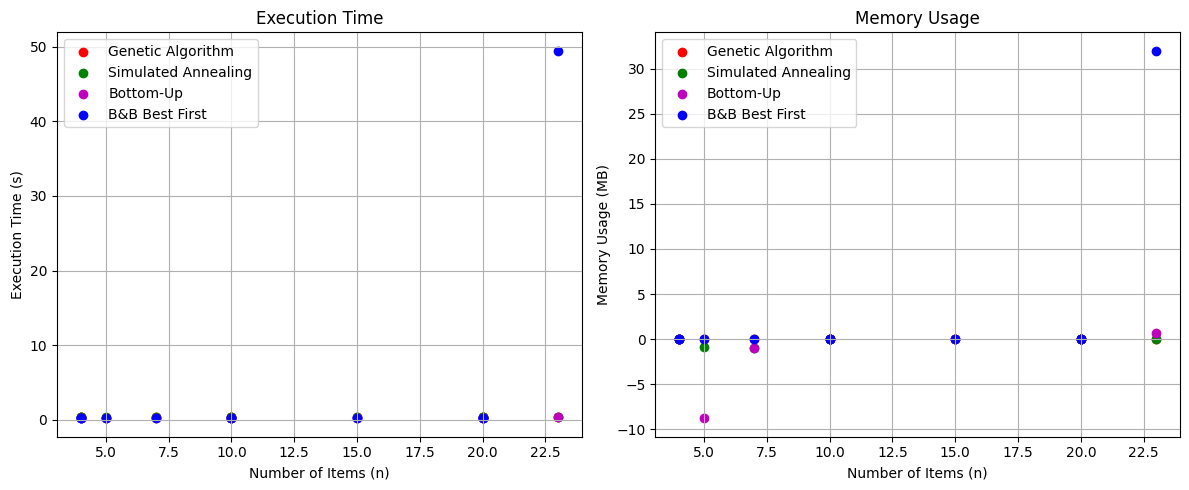

In [47]:
n_values = np.array(n_values)
plt.figure(figsize=(12, 5))

# plot times
plt.subplot(1, 2, 1)
colors = ['r', 'g', 'm', 'b']
for (method_name, times), color in zip(method_times.items(), colors):
    time_m = np.array(times)  
    plt.scatter(n_values, time_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.title("Execution Time")

# Plot memory usage
plt.subplot(1, 2, 2)
for (method_name, memories), color in zip(method_memory.items(), colors):
    memory_m = np.array(memories) 
    plt.scatter(n_values, memory_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Memory Usage (MB)")
plt.legend()
plt.grid(True)
plt.title("Memory Usage")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Execution Time')

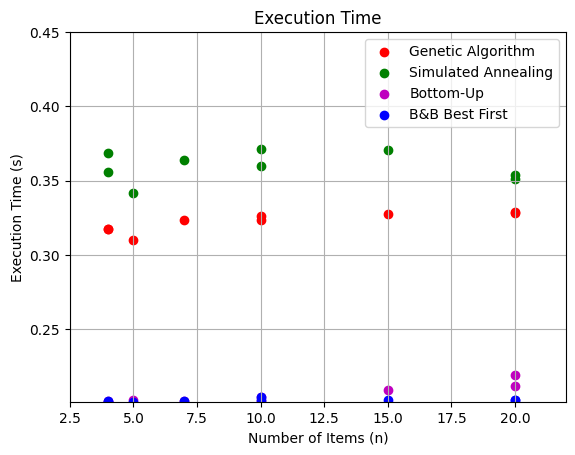

In [48]:
for (method_name, times), color in zip(method_times.items(), colors):
    time_m = np.array(times)  
    plt.scatter(n_values, time_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlim([2.5, 22.0])  
plt.ylim([min(time_m), 0.45])
plt.xlabel("Number of Items (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.title("Execution Time")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    In this first implementation, low parameters were used because low-dimensional examples are simpler to solve. With a population of 100 candidates and only 10 generations, it was possible to achieve estimated results very close to the optimal ones, with low standard deviation. However, the execution time was slightly higher compared to exact methods, making the use of the Genetic Algorithm infeasible for these small knapsack instances.
  </p>
</div>

#### Large Scale

In [49]:
datasets = []
N_values = []
W_values = []
listing = os.listdir("./instances_01_KP/large_scale/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    print(infile)
    path = os.path.join("./instances_01_KP/large_scale/", infile)
    # path = os.path.join("./instances_01_KP/large_scale/knapPI_1_200_1000_1")
    
    parts = infile.split("_")
    N = int(parts[2])  
    W = int(parts[3])  
    
    N_values.append(N)
    W_values.append(W)

    with open(path, "r") as f:
        lines = f.readlines()[:-1]  
    
    data = np.loadtxt(lines)
    datasets.append(data)
    break
    

knapPI_1_200_1000_1


In [51]:
methods = {
    "Genetic Algorithm": knapsack_genetic,
    "Simulated Annealing": simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    # "B&B Best First": KPBB_BestFirst
}

n_values, method_times, method_memory = compare_knapsack_methods(methods, datasets, "Large", W_values, N_values)


=== Problem with 200 items and 1000 capacity ===
Genetic Algorithm, Estimated Best value: 0.00 ± 0.00
Time: 0.4586s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 9584.00 ± 591.31
Time: 0.5275s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 11238.0
Time: 0.2564s | Memory: 0.0000 MB



<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It was observed that the algorithm was unable to generate an initial population with valid candidates (that did not exceed the maximum weight), as the knapsack often exceeds the weight limit with only 2 or 3 items. This means that an adapted method is needed for initializing the initial population.
  </p>
</div>

In [52]:
def knapsack_genetic(values, weights, W, pop_size=1000, generations=500, mutation_rate=0.05, tournament_size=5):
    num_items = len(values)

    def fitness(individual):
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else total_value * (W / total_weight)  # Penalization

    def selection(population):
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2):
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual):
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]
        return individual

    def generate_valid_solution(): # generates a solution by adding itens
        indices = np.argsort(weights)  # Orders itens
        solution = np.zeros(num_items, dtype=int)
        total_weight = 0
        for i in indices:
            if total_weight + weights[i] <= W:
                solution[i] = 1
                total_weight += weights[i]
        return solution

    # Initializes population with valid itens
    population = np.array([generate_valid_solution() for _ in range(pop_size)])

    for _ in range(generations):
        new_population = []
        for _ in range(pop_size):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutation(child)

            while np.dot(child, weights) > W:
                ones = np.where(child == 1)[0]  
                if len(ones) == 0:
                    break 
                child[np.random.choice(ones)] = 0

            new_population.append(child)

        population = np.array(new_population)

    best_individual = max(population, key=fitness)
    return best_individual, fitness(best_individual) 

In [53]:
methods = {
    "Genetic Algorithm": knapsack_genetic,
    "Simulated Annealing": simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    # "B&B Best First": KPBB_BestFirst
}

n_values, method_times, method_memory = compare_knapsack_methods(methods, datasets, "Large", W_values, N_values)


=== Problem with 200 items and 1000 capacity ===
Genetic Algorithm, Estimated Best value: 4289.00 ± 109.40
Time: 243.7000s | Memory: 3.6250 MB

Simulated Annealing, Estimated Best value: 9561.33 ± 793.64
Time: 0.5080s | Memory: -4.4141 MB

Bottom-Up, Optimal value: 11238.0
Time: 0.2466s | Memory: 0.7500 MB



<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    In this new version of the function, instead of generating random vectors and hoping that some are valid, items were sorted by weight and then added one by one until reaching the maximum weight. Additionally, the fitness function was adjusted to accept invalid solutions, but these were penalized below zero to prevent all fitness values from being zero, as seen previously.
  </p>
  <p>
    However, even with this approach, the algorithm did not prove efficient in selecting the optimal knapsack. With a population of 1000 candidates and 500 generations, the result was significantly below the optimal value and had a much longer execution time. Because of this, increasing the hyperparameters to achieve better results is unfeasible due to the excessive increase in execution time.
  </p>
</div>